# Notebook Python - Exploitation de CSV (Projet P8)

Ce notebook permet de charger, nettoyer, combiner et analyser des fichiers CSV issus de Snowflake/DBT.

Jeux de donnees attendus (exemples):
- `fct_profil_sociodem.csv`
- `fct_insee_par_region_age.csv`

## 1) Configurer l'environnement Python

Importer les bibliotheques principales et definir les chemins de travail.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / 'exports'
OUT_DIR = ROOT_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repertoire de travail :', ROOT_DIR)
print('Dossier CSV attendu  :', DATA_DIR)
print('Dossier sorties      :', OUT_DIR)

## 2) Lister et charger les fichiers CSV

On liste le dossier de donnees et on charge les CSV attendus avec un fallback d'encodage.

In [ ]:
EXPECTED_FILES = {
    'etudiants': 'fct_profil_sociodem.csv',
    'insee': 'fct_insee_par_region_age.csv',
}

OPTIONAL_FILES = {
    'summary': 'fct_summary_analysis.csv',
}


def list_csv_files(folder: Path):
    if not folder.exists():
        print(f"Le dossier {folder} n'existe pas.")
        return []
    files = sorted(folder.glob('*.csv'))
    if files:
        print('CSV detectes:')
        for f in files:
            print(' -', f.name)
    else:
        print('Aucun CSV detecte dans', folder)
    return files


def read_csv_with_fallback(path: Path, sep=',', dtype=None):
    for enc in ('utf-8', 'latin-1'):
        try:
            return pd.read_csv(path, sep=sep, encoding=enc, dtype=dtype), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, f"Impossible de lire {path.name} avec utf-8 ou latin-1")


available = list_csv_files(DATA_DIR)

paths = {k: DATA_DIR / v for k, v in EXPECTED_FILES.items()}
optional_paths = {k: DATA_DIR / v for k, v in OPTIONAL_FILES.items()}

missing = [p.name for p in paths.values() if not p.exists()]
if missing:
    print('\nFichiers manquants:', missing)
    print("Place les exports Snowflake dans le dossier 'exports' puis relance cette cellule.")

optional_missing = [p.name for p in optional_paths.values() if not p.exists()]
if optional_missing:
    print('\nFichiers optionnels non detectes:', optional_missing)
    print("Le notebook fonctionnera quand meme sans ces fichiers.")

CSV detectes:
 - fct_insee_par_region_age.csv
 - fct_profil_sociodem.csv
 - fct_summary_analysis.csv
 - stg_etudiants.csv
 - stg_insee_population.csv


In [ ]:
if not missing:
    df_etu, enc_etu = read_csv_with_fallback(paths['etudiants'])
    df_insee, enc_insee = read_csv_with_fallback(paths['insee'])

    print(f"fct_profil_sociodem.csv charge avec encodage: {enc_etu}")
    print(f"fct_insee_par_region_age.csv charge avec encodage: {enc_insee}")
    print('Shape etudiants :', df_etu.shape)
    print('Shape insee     :', df_insee.shape)

    summary_path = optional_paths['summary']
    if summary_path.exists():
        df_summary, enc_summary = read_csv_with_fallback(summary_path)
        print(f"fct_summary_analysis.csv charge avec encodage: {enc_summary}")
        print('Shape summary   :', df_summary.shape)
    else:
        df_summary = pd.DataFrame()
        print('fct_summary_analysis.csv non charge (optionnel).')
else:
    df_etu = pd.DataFrame()
    df_insee = pd.DataFrame()
    df_summary = pd.DataFrame()

fct_profil_sociodem.csv charge avec encodage: utf-8
fct_insee_par_region_age.csv charge avec encodage: utf-8
Shape etudiants : (862, 6)
Shape insee     : (672, 7)
fct_summary_analysis.csv charge avec encodage: utf-8
Shape summary   : (112, 9)


## 3) Inspecter la structure et la qualite des donnees

On controle types, valeurs manquantes, doublons et unicite de grain.

In [ ]:
def quality_report(df: pd.DataFrame, name: str):
    print(f"\n===== {name} =====")
    display(df.head())
    print('Dimensions:', df.shape)
    print('\nTypes:')
    display(df.dtypes.to_frame('dtype'))
    print('\nValeurs manquantes:')
    miss = df.isna().sum().sort_values(ascending=False)
    display(miss.to_frame('nb_manquants'))
    print('\nDoublons complets:', df.duplicated().sum())


if not df_etu.empty:
    quality_report(df_etu, 'fct_profil_sociodem')

if not df_insee.empty:
    quality_report(df_insee, 'fct_insee_par_region_age')

if not df_summary.empty:
    quality_report(df_summary, 'fct_summary_analysis')

if not df_etu.empty:
    grain_etu = ['YEAR_PATH_STARTED', 'REGION', 'AGE_GROUP', 'GENDER']
    if set(grain_etu).issubset(df_etu.columns):
        dup_grain_etu = df_etu.duplicated(subset=grain_etu).sum()
        print('\nDoublons sur grain etudiants', grain_etu, ':', dup_grain_etu)

if not df_insee.empty:
    grain_insee = ['YEAR', 'REGION', 'AGE_GROUP', 'GENDER']
    if set(grain_insee).issubset(df_insee.columns):
        dup_grain_insee = df_insee.duplicated(subset=grain_insee).sum()
        print('Doublons sur grain insee', grain_insee, ':', dup_grain_insee)

if not df_summary.empty:
    grain_summary = ['YEAR', 'REGION', 'GENDER']
    if set(grain_summary).issubset([c.upper() for c in df_summary.columns]):
        cols_upper_summary = {c.upper(): c for c in df_summary.columns}
        subset_cols = [cols_upper_summary[c] for c in grain_summary]
        dup_grain_summary = df_summary.duplicated(subset=subset_cols).sum()
        print('Doublons sur grain summary', grain_summary, ':', dup_grain_summary)

# ---- Controles supplementaires sur fct_profil_sociodem ----
if not df_etu.empty:
    cols_upper = {c.upper(): c for c in df_etu.columns}
    print("\n===== Controles additionnels: fct_profil_sociodem =====")

    print(f"Nombre de lignes (inscriptions brutes)       : {len(df_etu):,}")

    stg_path = DATA_DIR / 'stg_etudiants.csv'
    if stg_path.exists():
        df_stg, enc_stg = read_csv_with_fallback(stg_path)
        user_col = next((c for c in df_stg.columns if c.upper() == 'USER_ID'), None)
        if user_col:
            nb_unique = df_stg[user_col].nunique()
            print(f"Etudiants uniques (USER_ID distincts)        : {nb_unique:,}  [source: stg_etudiants.csv]")
        else:
            print("stg_etudiants.csv trouve mais colonne USER_ID absente.")
            print("Colonnes disponibles:", list(df_stg.columns))
    else:
        col_nb = cols_upper.get('NB_ETUDIANTS')
        if col_nb:
            total_etu = pd.to_numeric(df_etu[col_nb], errors='coerce').sum()
            print(f"Somme NB_ETUDIANTS (inscrits x categorie)    : {total_etu:,.0f}")
            print(f"  -> Ce total inclut les doublons par PATH_CATEGORY_NAME.")
            print(f"     Pour les etudiants uniques (ex: 4010), exporter stg_etudiants.csv")
            print(f"     (SELECT * FROM STG_ETUDIANTS) dans le dossier exports/")

    col_region = cols_upper.get('REGION')
    if col_region:
        regions = df_etu[col_region].dropna().unique()
        print(f"\nNombre de regions distinctes                 : {len(regions)}")
        corse_vals = [r for r in regions if 'corse' in str(r).lower()]
        if corse_vals:
            print(f"Corse presente                               : OUI -> {sorted(corse_vals)}")
        else:
            print("Corse presente                               : NON (aucune valeur contenant 'corse')")

    col_year = cols_upper.get('YEAR_PATH_STARTED')
    if col_year:
        years = sorted(pd.to_numeric(df_etu[col_year], errors='coerce').dropna().unique().astype(int))
        print(f"\nAnnees disponibles ({len(years)})                    : {years}")

# ---- Verif Corse par table (pour eviter les ambiguities) ----
def corse_check(df: pd.DataFrame, table_name: str):
    if df.empty:
        print(f"{table_name:<45}: VIDE")
        return

    cols_upper_local = {c.upper(): c for c in df.columns}
    region_col = cols_upper_local.get('REGION') or cols_upper_local.get('INSEE_REGION')

    if not region_col:
        print(f"{table_name:<45}: colonne region absente")
        return

    region_values = df[region_col].dropna().astype(str)
    corse_values = sorted(v for v in region_values.unique() if 'corse' in v.lower())

    if corse_values:
        print(f"{table_name:<45}: OUI -> {corse_values}")
    else:
        print(f"{table_name:<45}: NON")

print("\n===== Presence de la Corse par table =====")
corse_check(df_etu, 'fct_profil_sociodem')
corse_check(df_insee, 'fct_insee_par_region_age')
corse_check(df_summary, 'fct_summary_analysis')

if not df_summary.empty:
    cols_summary = {c.upper(): c for c in df_summary.columns}
    join_scope_col = cols_summary.get('JOIN_SCOPE')
    region_col = cols_summary.get('REGION')
    if join_scope_col:
        print("\n===== Repartition JOIN_SCOPE (fct_summary_analysis) =====")
        display(df_summary[join_scope_col].value_counts(dropna=False).rename('nb_lignes').to_frame())

        if region_col:
            corse_mask = df_summary[region_col].astype(str).str.contains('corse', case=False, na=False)
            if corse_mask.any():
                print("\nJOIN_SCOPE pour les lignes Corse:")
                display(
                    df_summary.loc[corse_mask, [region_col, join_scope_col]]
                    .value_counts()
                    .rename('nb_lignes')
                    .to_frame()
                )


===== fct_profil_sociodem =====


,YEAR_PATH_STARTED,REGION,AGE_GROUP,GENDER,PATH_CATEGORY_NAME,NB_ETUDIANTS
0,2025,Auvergne-Rhône-Alpes,20-24 ans,F,Data,3
1,2025,Auvergne-Rhône-Alpes,20-24 ans,M,Data,9
2,2025,Auvergne-Rhône-Alpes,20-24 ans,Non renseigné,Data,1
3,2025,Auvergne-Rhône-Alpes,25-29 ans,F,Data,5
4,2025,Auvergne-Rhône-Alpes,25-29 ans,M,Data,18


Dimensions: (862, 6)

Types:


,dtype
YEAR_PATH_STARTED,int64
REGION,str
AGE_GROUP,str
GENDER,str
PATH_CATEGORY_NAME,str
NB_ETUDIANTS,int64



Valeurs manquantes:


...

,nb_manquants
ECART_POINTS,8
PART_ETUDIANTS,8
YEAR,0
REGION,0
GENDER,0
NB_ETUDIANTS,0
JOIN_SCOPE,0
POPULATION_INSEE,0
PART_INSEE,0



Doublons complets: 0

Doublons sur grain etudiants ['YEAR_PATH_STARTED', 'REGION', 'AGE_GROUP', 'GENDER'] : 0
Doublons sur grain insee ['YEAR', 'REGION', 'AGE_GROUP', 'GENDER'] : 0
Doublons sur grain summary ['YEAR', 'REGION', 'GENDER'] : 0

===== Controles additionnels: fct_profil_sociodem =====
Nombre de lignes (inscriptions brutes)       : 862
Etudiants uniques (USER_ID distincts)        : 4,010  [source: stg_etudiants.csv]

Nombre de regions distinctes                 : 13
Corse presente                               : NON (aucune valeur contenant 'corse')

Annees disponibles (4)                    : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

===== Presence de la Corse par table =====
fct_profil_sociodem                          : NON
fct_insee_par_region_age                     : OUI -> ['Corse']
fct_summary_analysis                         : OUI -> ['Corse']

===== Repartition JOIN_SCOPE (fct_summary_analysis) =====


,nb_lignes
JOIN_SCOPE,
matched,104
insee_only,8



JOIN_SCOPE pour les lignes Corse:


,,nb_lignes
REGION,JOIN_SCOPE,
Corse,insee_only,8


## 4) Nettoyer et standardiser les colonnes cles

Uniformiser noms de colonnes, categories et types pour faciliter les jointures et analyses.

In [ ]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip().upper() for c in out.columns]
    return out


def normalize_region(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.replace('Centre-Val de Loire', 'Centre-Val-de-Loire', regex=False)
    )


def normalize_gender(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .replace({'H': 'M', 'HOMME': 'M', 'FEMME': 'F'})
    )


if not df_etu.empty:
    etu = clean_columns(df_etu)
    etu['REGION'] = normalize_region(etu['REGION'])
    etu['GENDER'] = normalize_gender(etu['GENDER'])
    etu['YEAR_PATH_STARTED'] = pd.to_numeric(etu['YEAR_PATH_STARTED'], errors='coerce').astype('Int64')
    etu['NB_ETUDIANTS'] = pd.to_numeric(etu['NB_ETUDIANTS'], errors='coerce')
    etu['AGE_GROUP'] = etu['AGE_GROUP'].astype(str).str.strip()
else:
    etu = pd.DataFrame()

if not df_insee.empty:
    insee = clean_columns(df_insee)
    insee['REGION'] = normalize_region(insee['REGION'])
    insee['GENDER'] = normalize_gender(insee['GENDER'])
    insee['YEAR'] = pd.to_numeric(insee['YEAR'], errors='coerce').astype('Int64')
    insee['POPULATION_INSEE'] = pd.to_numeric(insee['POPULATION_INSEE'], errors='coerce')
    insee['AGE_GROUP'] = insee['AGE_GROUP'].astype(str).str.strip()
else:
    insee = pd.DataFrame()

if not df_summary.empty:
    summary = clean_columns(df_summary)
    summary['REGION'] = normalize_region(summary['REGION'])
    summary['GENDER'] = normalize_gender(summary['GENDER'])
    summary['YEAR'] = pd.to_numeric(summary['YEAR'], errors='coerce').astype('Int64')
    summary['NB_ETUDIANTS'] = pd.to_numeric(summary['NB_ETUDIANTS'], errors='coerce')
    summary['POPULATION_INSEE'] = pd.to_numeric(summary['POPULATION_INSEE'], errors='coerce')
    if 'PART_ETUDIANTS' in summary.columns:
        summary['PART_ETUDIANTS'] = pd.to_numeric(summary['PART_ETUDIANTS'], errors='coerce')
    if 'PART_INSEE' in summary.columns:
        summary['PART_INSEE'] = pd.to_numeric(summary['PART_INSEE'], errors='coerce')
    if 'ECART_POINTS' in summary.columns:
        summary['ECART_POINTS'] = pd.to_numeric(summary['ECART_POINTS'], errors='coerce')
else:
    summary = pd.DataFrame()

print('Colonnes etudiants :', list(etu.columns))
print('Colonnes insee     :', list(insee.columns))
print('Colonnes summary   :', list(summary.columns))

Colonnes etudiants : ['YEAR_PATH_STARTED', 'REGION', 'AGE_GROUP', 'GENDER', 'PATH_CATEGORY_NAME', 'NB_ETUDIANTS']
Colonnes insee     : ['YEAR', 'REGION', 'AGE_GROUP', 'GENDER', 'GENDER_LABEL', 'POPULATION_INSEE', 'NB_DEPARTMENTS']
Colonnes summary   : ['YEAR', 'REGION', 'GENDER', 'JOIN_SCOPE', 'NB_ETUDIANTS', 'POPULATION_INSEE', 'PART_ETUDIANTS', 'PART_INSEE', 'ECART_POINTS']


## 5) Combiner les jeux de donnees (jointures)

Comparer les parts etudiants et population INSEE par annee, region et genre.

In [ ]:
if not etu.empty and not insee.empty:
    etu_cmp = (
        etu[etu['GENDER'].isin(['F', 'M'])]
        .groupby(['YEAR_PATH_STARTED', 'REGION', 'GENDER'], as_index=False)['NB_ETUDIANTS']
        .sum()
        .rename(columns={'YEAR_PATH_STARTED': 'YEAR'})
    )

    insee_cmp = (
        insee[insee['GENDER'].isin(['F', 'M'])]
        .groupby(['YEAR', 'REGION', 'GENDER'], as_index=False)['POPULATION_INSEE']
        .sum()
    )

    etu_cmp['total_etu_region_annee'] = etu_cmp.groupby(['YEAR', 'REGION'])['NB_ETUDIANTS'].transform('sum')
    etu_cmp['part_etudiants'] = np.where(
        etu_cmp['total_etu_region_annee'] > 0,
        etu_cmp['NB_ETUDIANTS'] / etu_cmp['total_etu_region_annee'],
        np.nan
    )

    insee_cmp['total_insee_region_annee'] = insee_cmp.groupby(['YEAR', 'REGION'])['POPULATION_INSEE'].transform('sum')
    insee_cmp['part_insee'] = np.where(
        insee_cmp['total_insee_region_annee'] > 0,
        insee_cmp['POPULATION_INSEE'] / insee_cmp['total_insee_region_annee'],
        np.nan
    )

    comparaison_genre = etu_cmp.merge(
        insee_cmp[['YEAR', 'REGION', 'GENDER', 'part_insee']],
        on=['YEAR', 'REGION', 'GENDER'],
        how='outer',
        indicator=True
    )
    comparaison_genre['ecart_points'] = (comparaison_genre['part_etudiants'] - comparaison_genre['part_insee']) * 100

    print('Statut de jointure (_merge):')
    display(comparaison_genre['_merge'].value_counts(dropna=False).to_frame('nb_lignes'))
    display(comparaison_genre.head(20))
else:
    comparaison_genre = pd.DataFrame()
    print("Jointure non executee: CSV manquants ou non charges.")

Statut de jointure (_merge):


,nb_lignes
_merge,
both,104
right_only,8
left_only,0


,YEAR,REGION,GENDER,NB_ETUDIANTS,total_etu_region_annee,part_etudiants,part_insee,_merge,ecart_points
0,2022,Auvergne-Rhône-Alpes,F,31.0,97.0,0.319588,0.512656,both,-19.306860
1,2022,Auvergne-Rhône-Alpes,M,66.0,97.0,0.680412,0.487344,both,19.306860
2,2022,Bourgogne-Franche-Comté,F,5.0,20.0,0.250000,0.511839,both,-26.183901
3,2022,Bourgogne-Franche-Comté,M,15.0,20.0,0.750000,0.488161,both,26.183901
4,2022,Bretagne,F,7.0,27.0,0.259259,0.513291,both,-25.403217
5,2022,Bretagne,M,20.0,27.0,0.740741,0.486709,both,25.403217
6,2022,Centre-Val-de-Loire,F,4.0,23.0,0.173913,0.514583,both,-34.066998
7,2022,Centre-Val-de-Loire,M,19.0,23.0,0.826087,0.485417,both,34.066998
8,2022,Corse,F,NaN,NaN,NaN,0.515122,right_only,NaN
9,2022,Corse,M,NaN,NaN,NaN,0.484878,right_only,NaN


## 6) Calculer des indicateurs par annee, region, age et genre

Produire des tables analytiques pretes pour la presentation.

In [ ]:
def standardize_year_column(df: pd.DataFrame, candidate_cols=('YEAR', 'YEAR_x', 'YEAR_y')) -> pd.DataFrame:
    """Force une colonne YEAR unique en privilégiant YEAR, puis YEAR_x, puis YEAR_y."""
    out = df.copy()
    existing = [c for c in candidate_cols if c in out.columns]
    if not existing:
        return out

    # Prend la première colonne disponible comme référence
    out['YEAR'] = out[existing[0]]

    # Si d'autres colonnes année existent, on comble les NA avec celles-ci
    for c in existing[1:]:
        out['YEAR'] = out['YEAR'].fillna(out[c])

    # Nettoie les colonnes suffixées pour éviter l'ambiguïté
    for c in ('YEAR_x', 'YEAR_y'):
        if c in out.columns:
            out = out.drop(columns=c)

    out['YEAR'] = pd.to_numeric(out['YEAR'], errors='coerce').astype('Int64')
    return out


if not etu.empty:
    trend_etu_year_gender = (
        etu.groupby(['YEAR_PATH_STARTED', 'GENDER'], as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values(['YEAR_PATH_STARTED', 'GENDER'])
    )
    trend_etu_year_region = (
        etu.groupby(['YEAR_PATH_STARTED', 'REGION'], as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values(['YEAR_PATH_STARTED', 'NB_ETUDIANTS'], ascending=[True, False])
    )
    trend_etu_year_total = (
        etu.groupby('YEAR_PATH_STARTED', as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values('YEAR_PATH_STARTED')
    )
    repartition_genre_oc = (
        etu[etu['GENDER'].isin(['F', 'M'])]
        .groupby('GENDER', as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values('NB_ETUDIANTS', ascending=False)
    )
    repartition_age_oc = (
        etu.groupby('AGE_GROUP', as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values('NB_ETUDIANTS', ascending=False)
    )
    repartition_region_oc = (
        etu.groupby('REGION', as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values('NB_ETUDIANTS', ascending=False)
    )

    # Evolution de la repartition H/F en % par annee
    etu_fm = etu[etu['GENDER'].isin(['F', 'M'])].copy()
    trend_gender_year_pct = (
        etu_fm.groupby(['YEAR_PATH_STARTED', 'GENDER'], as_index=False)['NB_ETUDIANTS'].sum()
    )
    total_fm_year = trend_gender_year_pct.groupby('YEAR_PATH_STARTED')['NB_ETUDIANTS'].transform('sum')
    trend_gender_year_pct['part_genre'] = np.where(
        total_fm_year > 0,
        trend_gender_year_pct['NB_ETUDIANTS'] / total_fm_year,
        np.nan
    )
    trend_gender_year_pct = trend_gender_year_pct.sort_values(['YEAR_PATH_STARTED', 'GENDER'])

    # Repartition globale OC (F/M) pour comparaison avec population de reference INSEE
    gender_oc_global = (
        etu_fm.groupby('GENDER', as_index=False)['NB_ETUDIANTS'].sum()
    )
    total_oc_fm = gender_oc_global['NB_ETUDIANTS'].sum()
    gender_oc_global['part_oc'] = gender_oc_global['NB_ETUDIANTS'] / total_oc_fm

    # Tendance des tranches d'age par annee (rajeunissement / vieillissement)
    trend_etu_age_year = (
        etu.groupby(['YEAR_PATH_STARTED', 'AGE_GROUP'], as_index=False)['NB_ETUDIANTS']
        .sum()
        .sort_values(['YEAR_PATH_STARTED', 'AGE_GROUP'])
    )
    total_par_annee = trend_etu_age_year.groupby('YEAR_PATH_STARTED')['NB_ETUDIANTS'].transform('sum')
    trend_etu_age_year['part_age'] = np.where(
        total_par_annee > 0,
        trend_etu_age_year['NB_ETUDIANTS'] / total_par_annee,
        np.nan
    )

    display(trend_etu_year_total)
    display(trend_etu_year_gender.head(20))
    display(trend_etu_year_region.head(20))
    display(trend_etu_age_year.head(20))
    display(trend_gender_year_pct)
else:
    trend_etu_year_total = pd.DataFrame()
    trend_etu_year_gender = pd.DataFrame()
    trend_etu_year_region = pd.DataFrame()
    repartition_genre_oc = pd.DataFrame()
    repartition_age_oc = pd.DataFrame()
    repartition_region_oc = pd.DataFrame()
    trend_etu_age_year = pd.DataFrame()
    trend_gender_year_pct = pd.DataFrame()
    gender_oc_global = pd.DataFrame()

if not insee.empty:
    trend_insee_year_gender = (
        insee[insee['GENDER'].isin(['F', 'M'])]
        .groupby(['YEAR', 'GENDER'], as_index=False)['POPULATION_INSEE']
        .sum()
        .sort_values(['YEAR', 'GENDER'])
    )
    trend_insee_year_gender = standardize_year_column(trend_insee_year_gender)
    display(trend_insee_year_gender.head(20))
else:
    trend_insee_year_gender = pd.DataFrame()

if not etu.empty and not insee.empty:
    oc_gender_year = (
        etu[etu['GENDER'].isin(['F', 'M'])]
        .groupby(['YEAR_PATH_STARTED', 'GENDER'], as_index=False)['NB_ETUDIANTS']
        .sum()
        .rename(columns={'YEAR_PATH_STARTED': 'YEAR', 'NB_ETUDIANTS': 'value_oc'})
    )
    insee_gender_year = (
        insee[insee['GENDER'].isin(['F', 'M'])]
        .groupby(['YEAR', 'GENDER'], as_index=False)['POPULATION_INSEE']
        .sum()
        .rename(columns={'POPULATION_INSEE': 'value_insee'})
    )

    oc_f = oc_gender_year[oc_gender_year['GENDER'] == 'F'].copy()
    insee_f = insee_gender_year[insee_gender_year['GENDER'] == 'F'].copy()

    oc_total = oc_gender_year.groupby('YEAR', as_index=False)['value_oc'].sum().rename(columns={'value_oc': 'total_oc'})
    insee_total = insee_gender_year.groupby('YEAR', as_index=False)['value_insee'].sum().rename(columns={'value_insee': 'total_insee'})

    women_oc_vs_insee = (
        oc_f.merge(oc_total, on='YEAR', how='left')
        .merge(insee_f[['YEAR', 'value_insee']], on='YEAR', how='left')
        .merge(insee_total, on='YEAR', how='left')
    )
    women_oc_vs_insee = standardize_year_column(women_oc_vs_insee)

    women_oc_vs_insee['part_f_oc'] = np.where(
        women_oc_vs_insee['total_oc'] > 0,
        women_oc_vs_insee['value_oc'] / women_oc_vs_insee['total_oc'],
        np.nan
    )
    women_oc_vs_insee['part_f_insee'] = np.where(
        women_oc_vs_insee['total_insee'] > 0,
        women_oc_vs_insee['value_insee'] / women_oc_vs_insee['total_insee'],
        np.nan
    )
    women_oc_vs_insee = women_oc_vs_insee.sort_values('YEAR')
    display(women_oc_vs_insee[['YEAR', 'part_f_oc', 'part_f_insee']])

    # Comparaison OC vs population de reference INSEE (repartition H/F globale, toutes annees)
    insee_fm_global = (
        insee[insee['GENDER'].isin(['F', 'M'])]
        .groupby('GENDER', as_index=False)['POPULATION_INSEE'].sum()
    )
    total_insee_fm = insee_fm_global['POPULATION_INSEE'].sum()
    insee_fm_global['part_insee'] = insee_fm_global['POPULATION_INSEE'] / total_insee_fm

    gender_pop_active_cmp = gender_oc_global.merge(
        insee_fm_global[['GENDER', 'part_insee']],
        on='GENDER',
        how='outer'
    )
    gender_pop_active_cmp['ecart_pts'] = (
        gender_pop_active_cmp['part_oc'] - gender_pop_active_cmp['part_insee']
    ) * 100
    display(gender_pop_active_cmp[['GENDER', 'part_oc', 'part_insee', 'ecart_pts']]
            .style.format({'part_oc': '{:.1%}', 'part_insee': '{:.1%}', 'ecart_pts': '{:+.2f} pts'}))

    # Sur/sous-représentation par région (OC vs population INSEE)
    part_oc_region = (
        etu.groupby('REGION', as_index=False)['NB_ETUDIANTS'].sum()
    )
    total_oc_all = part_oc_region['NB_ETUDIANTS'].sum()
    part_oc_region['part_oc'] = part_oc_region['NB_ETUDIANTS'] / total_oc_all

    part_insee_region = (
        insee.groupby('REGION', as_index=False)['POPULATION_INSEE'].sum()
    )
    total_insee_all = part_insee_region['POPULATION_INSEE'].sum()
    part_insee_region['part_insee'] = part_insee_region['POPULATION_INSEE'] / total_insee_all

    region_repr = part_oc_region.merge(
        part_insee_region[['REGION', 'part_insee', 'POPULATION_INSEE']],
        on='REGION',
        how='outer'
    )
    region_repr['ecart_points'] = (region_repr['part_oc'] - region_repr['part_insee']) * 100
    region_repr['surrepresentation'] = region_repr['ecart_points'].apply(
        lambda x: 'Sur-representee' if x > 0 else ('Sous-representee' if x < 0 else 'Neutre')
    )
    region_repr = region_repr.sort_values('ecart_points', ascending=False).reset_index(drop=True)
    display(region_repr[['REGION', 'part_oc', 'part_insee', 'ecart_points', 'surrepresentation']]
            .style.format({'part_oc': '{:.1%}', 'part_insee': '{:.1%}', 'ecart_points': '{:+.2f} pts'})
            .background_gradient(subset='ecart_points', cmap='RdYlGn', vmin=-5, vmax=5))
else:
    women_oc_vs_insee = pd.DataFrame()
    region_repr = pd.DataFrame()
    gender_pop_active_cmp = pd.DataFrame()

if not summary.empty:
    trend_summary_year = (
        summary.groupby('YEAR', as_index=False)
        .agg(
            nb_etudiants=('NB_ETUDIANTS', 'sum'),
            population_insee=('POPULATION_INSEE', 'sum'),
            ecart_points_moyen=('ECART_POINTS', 'mean')
        )
        .sort_values('YEAR')
    )
    trend_summary_year = standardize_year_column(trend_summary_year)
    display(trend_summary_year)
else:
    trend_summary_year = pd.DataFrame()


,YEAR_PATH_STARTED,NB_ETUDIANTS
0,2022,1696
1,2023,1150
2,2024,850
3,2025,951


,YEAR_PATH_STARTED,GENDER,NB_ETUDIANTS
0,2022,F,302
1,2022,M,688
2,2022,Non renseigné,706
3,2023,F,247
4,2023,M,513
5,2023,Non renseigné,390
6,2024,F,217
7,2024,M,547
8,2024,Non renseigné,86
9,2025,F,291


,YEAR_PATH_STARTED,REGION,NB_ETUDIANTS
12,2022,Île-de-France,762
0,2022,Auvergne-Rhône-Alpes,171
8,2022,Nouvelle-Aquitaine,117
9,2022,Occitanie,115
6,2022,Hauts-de-France,113
11,2022,Provence-Alpes-Côte d'Azur,100
5,2022,Grand Est,95
10,2022,Pays de la Loire,65
2,2022,Bretagne,46
3,2022,Centre-Val-de-Loire,36


,YEAR_PATH_STARTED,AGE_GROUP,NB_ETUDIANTS,part_age
0,2022,20-24 ans,21,0.012382
1,2022,25-29 ans,250,0.147406
2,2022,30-34 ans,460,0.271226
3,2022,35-39 ans,336,0.198113
4,2022,40-44 ans,268,0.158019
5,2022,45-49 ans,149,0.087854
6,2022,50-54 ans,106,0.062500
7,2022,55-59 ans,65,0.038325
8,2022,60 ans ou plus,41,0.024175
9,2023,20-24 ans,28,0.024348


,YEAR_PATH_STARTED,GENDER,NB_ETUDIANTS,part_genre
0,2022,F,302,0.305051
1,2022,M,688,0.694949
2,2023,F,247,0.325000
3,2023,M,513,0.675000
4,2024,F,217,0.284031
5,2024,M,547,0.715969
6,2025,F,291,0.328072
7,2025,M,596,0.671928


,YEAR,GENDER,POPULATION_INSEE
0,2022,F,105277560
1,2022,M,98903061
2,2023,F,105516933
3,2023,M,99221313
4,2024,F,105764928
5,2024,M,99544920
6,2025,F,105979215
7,2025,M,99837633


,YEAR,part_f_oc,part_f_insee
0,2022,0.305051,0.515610
1,2023,0.325000,0.515375
2,2024,0.284031,0.515148
3,2025,0.328072,0.514920


,GENDER,part_oc,part_insee,ecart_pts
0,F,31.1%,51.5%,-20.45 pts
1,M,68.9%,48.5%,+20.45 pts


,REGION,part_oc,part_insee,ecart_points,surrepresentation
0,Île-de-France,45.6%,18.2%,+27.45 pts,Sur-representee
1,Centre-Val-de-Loire,2.6%,3.8%,-1.15 pts,Sous-representee
2,Provence-Alpes-Côte d'Azur,6.3%,7.6%,-1.27 pts,Sous-representee
3,Bretagne,3.0%,5.0%,-2.06 pts,Sous-representee
4,DROM,1.0%,3.3%,-2.28 pts,Sous-representee
5,Pays de la Loire,3.4%,5.7%,-2.30 pts,Sous-representee
6,Hauts-de-France,6.5%,8.8%,-2.30 pts,Sous-representee
7,Normandie,2.5%,4.9%,-2.43 pts,Sous-representee
8,Bourgogne-Franche-Comté,1.7%,4.2%,-2.50 pts,Sous-representee
9,Grand Est,5.5%,8.0%,-2.53 pts,Sous-representee


,YEAR,nb_etudiants,population_insee,ecart_points_moyen
0,2022,990,204180621,0.0
1,2023,760,204738246,0.0
2,2024,764,205309848,0.0
3,2025,887,205816848,0.0


## 7) Visualiser les resultats

Graphiques pour comparer distributions et tendances.

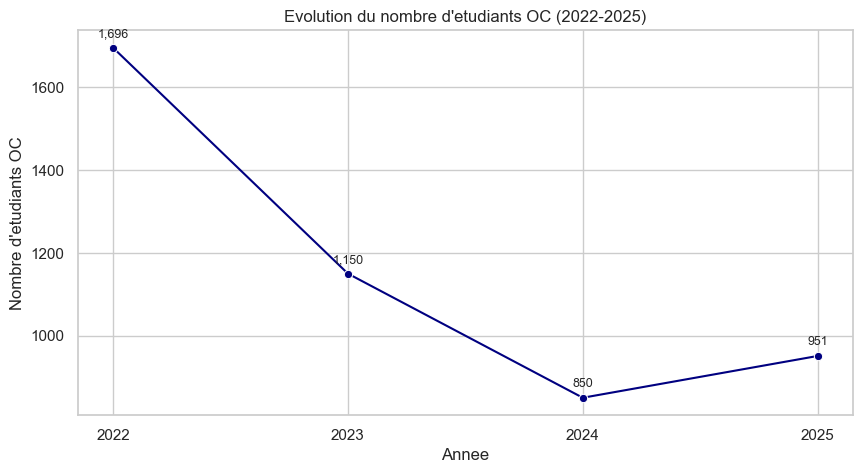

C:\Users\feria\AppData\Local\Temp\ipykernel_26220\4178952944.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


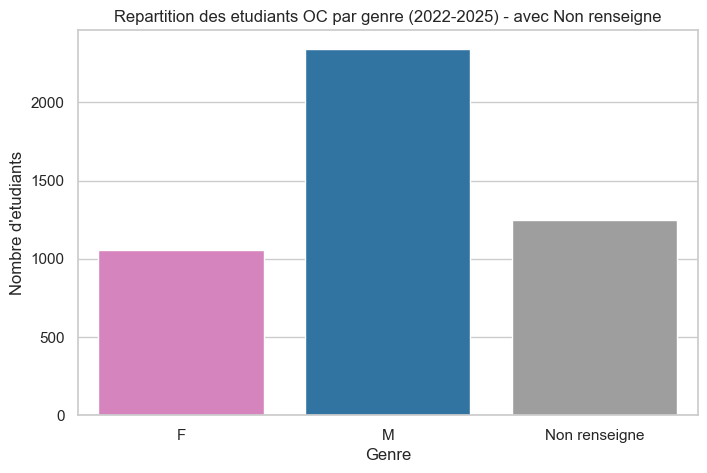

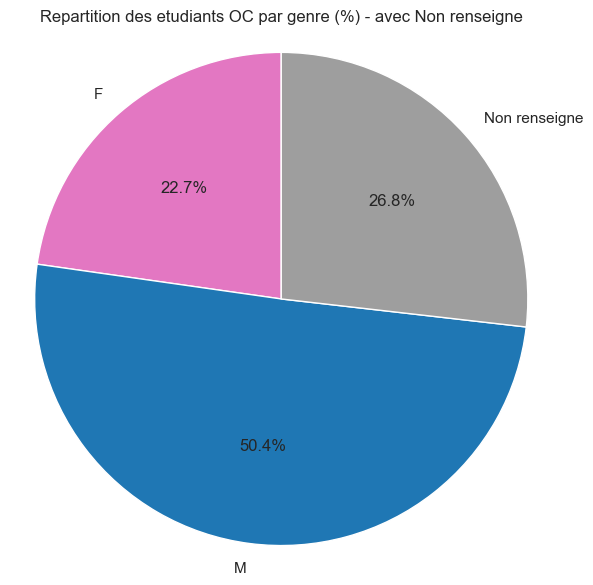

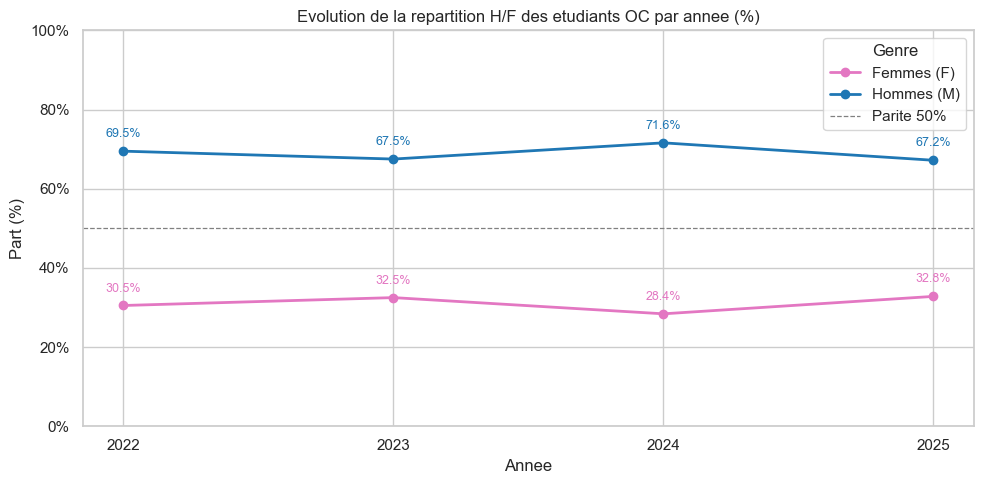

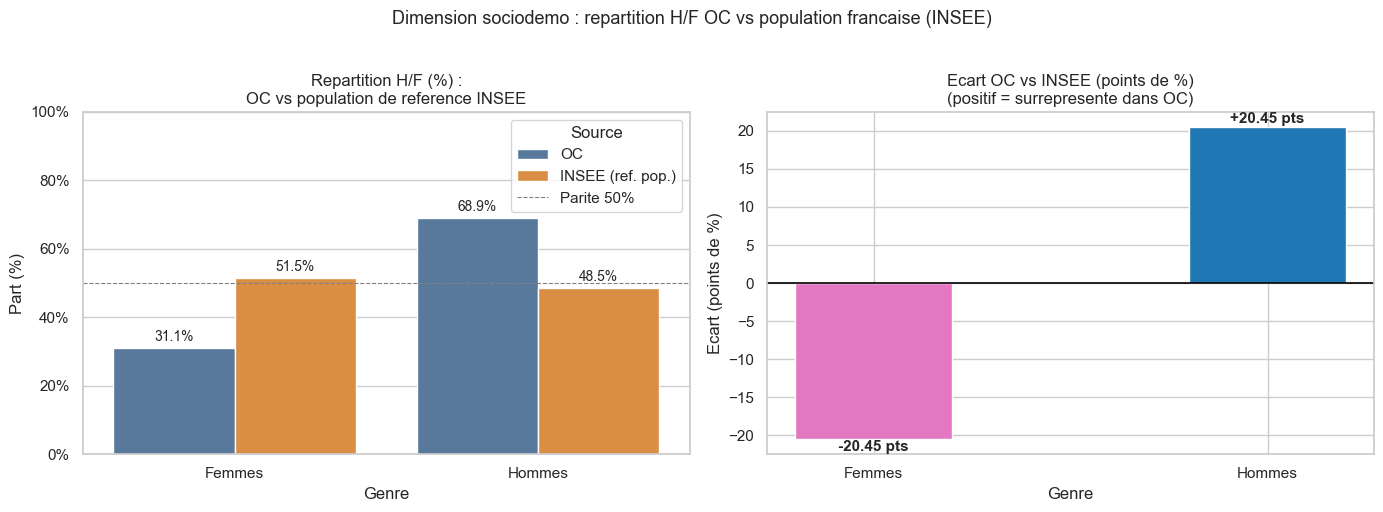

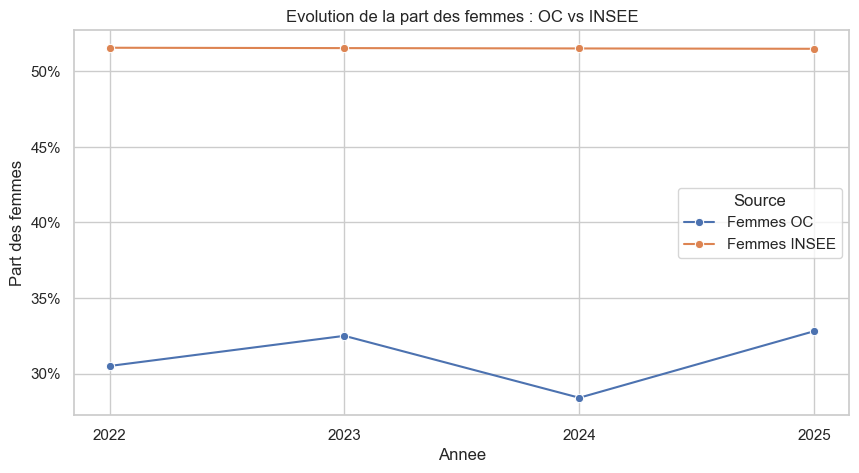

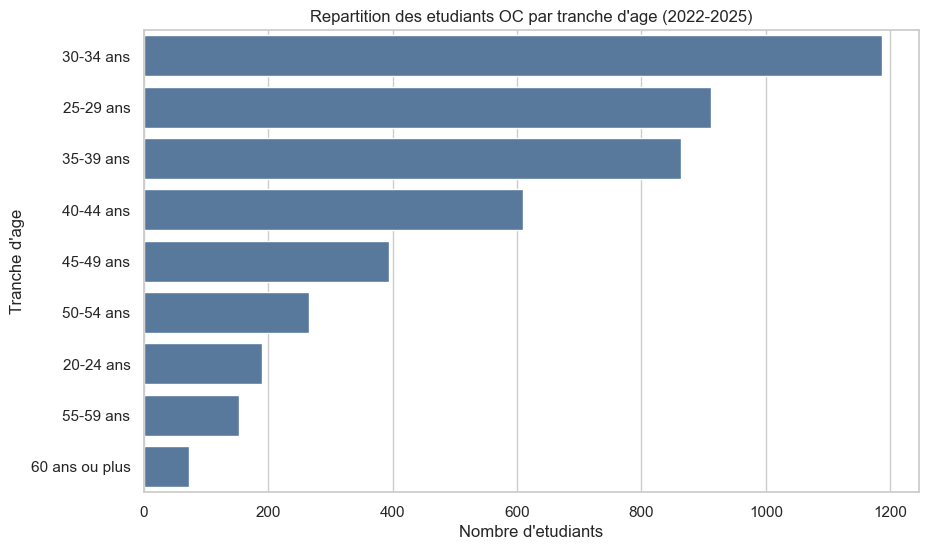

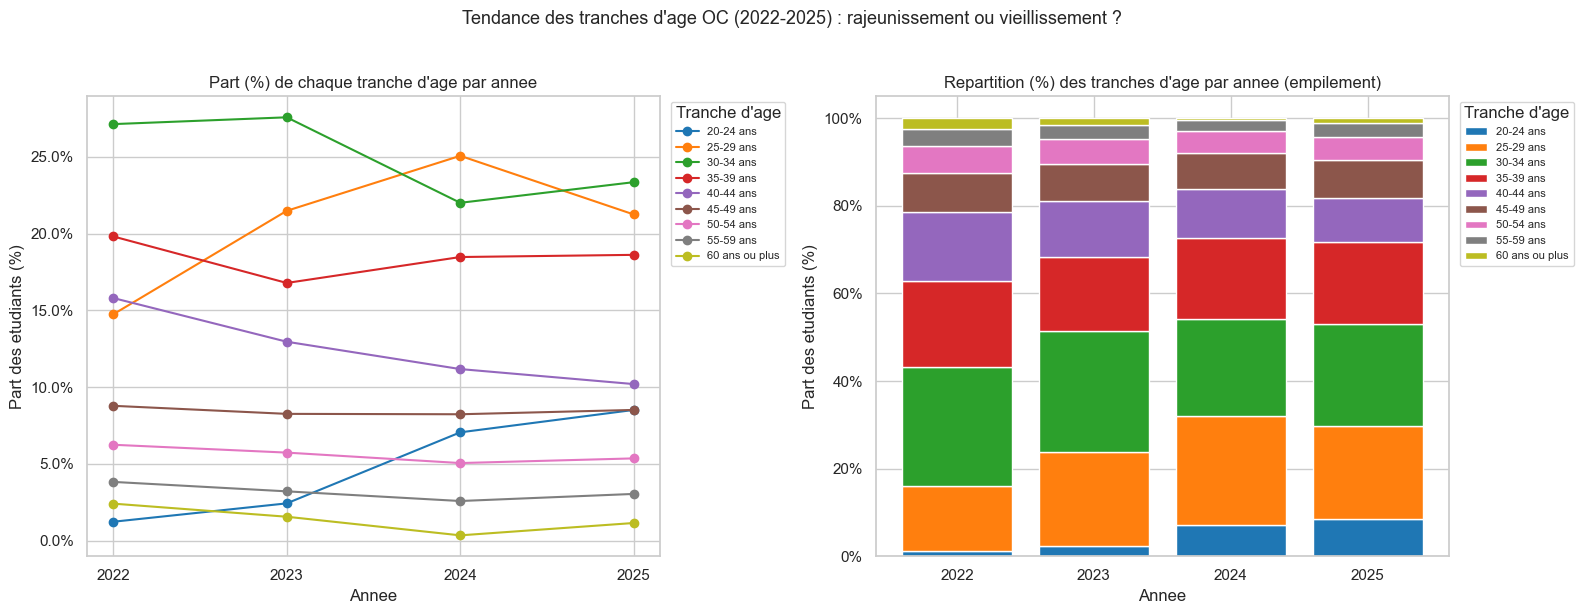


Variation de la part (points) entre 2022 et 2025:
  40-44 ans           : -5.60 pts -> rajeunissement
  30-34 ans           : -3.78 pts -> rajeunissement
  60 ans ou plus      : -1.26 pts -> rajeunissement
  35-39 ans           : -1.20 pts -> rajeunissement
  50-54 ans           : -0.89 pts -> rajeunissement
  55-59 ans           : -0.78 pts -> rajeunissement
  45-49 ans           : -0.27 pts -> rajeunissement
  25-29 ans           : +6.50 pts -> vieillissement
  20-24 ans           : +7.28 pts -> vieillissement


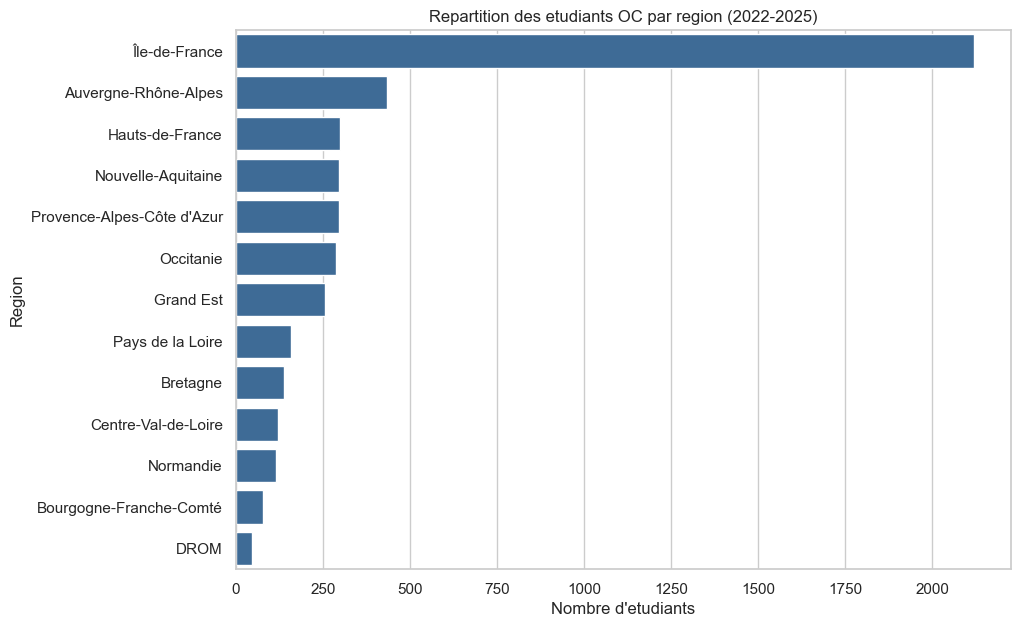

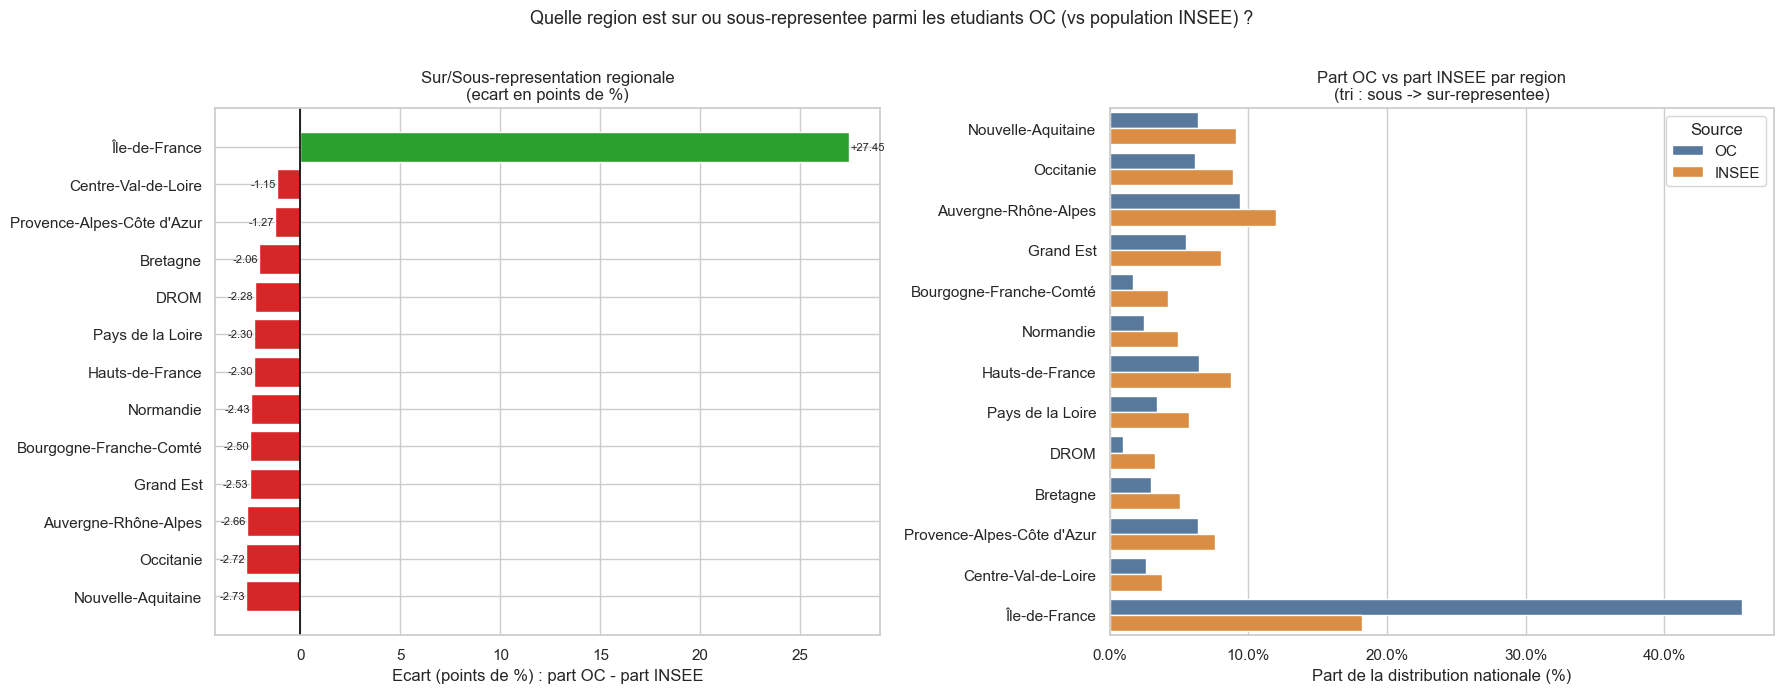


Top regions SUR-representees (OC > population nationale) :
  Île-de-France                      : 45.6% OC vs 18.2% INSEE  (+27.45 pts)

Top regions SOUS-representees (OC < population nationale) :
  Nouvelle-Aquitaine                 : 6.4% OC vs 9.1% INSEE  (-2.73 pts)
  Occitanie                          : 6.2% OC vs 8.9% INSEE  (-2.72 pts)
  Auvergne-Rhône-Alpes               : 9.4% OC vs 12.0% INSEE  (-2.66 pts)
  Grand Est                          : 5.5% OC vs 8.0% INSEE  (-2.53 pts)
  Bourgogne-Franche-Comté            : 1.7% OC vs 4.2% INSEE  (-2.50 pts)


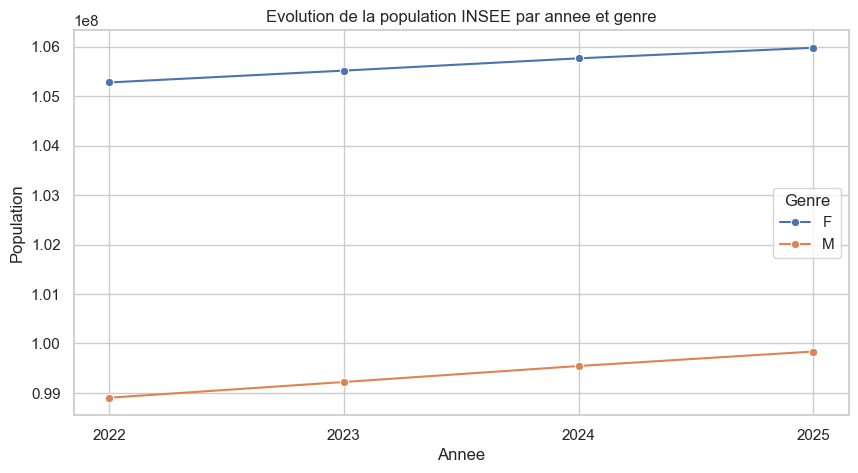

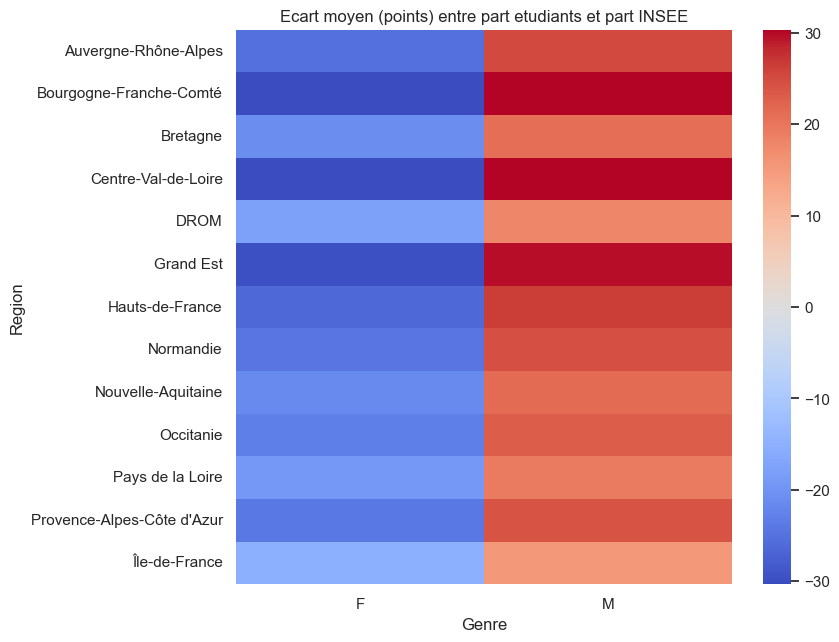

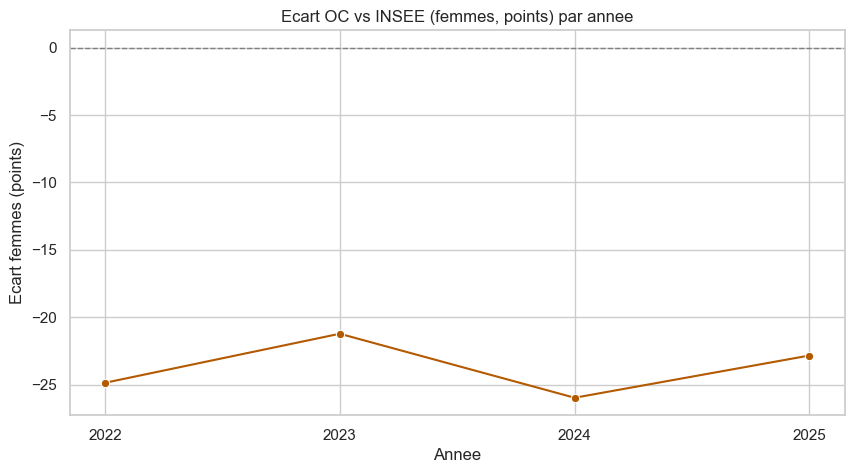

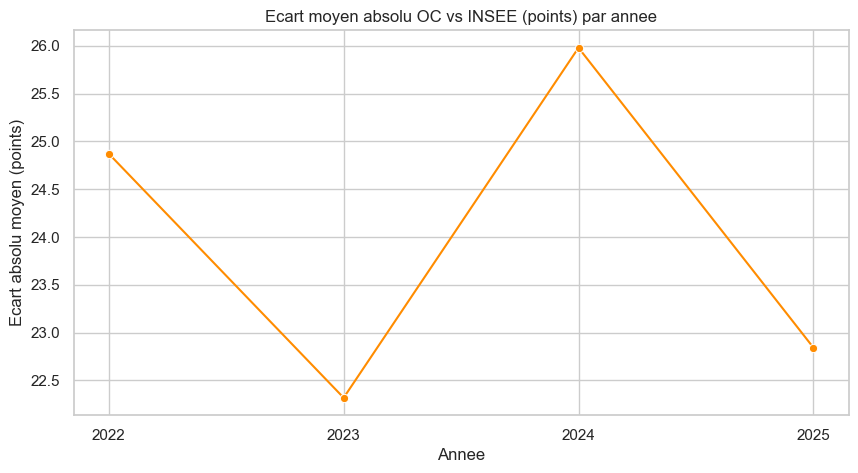

In [ ]:
# 1) Evolution dans le temps du nombre d'etudiants OC
if not trend_etu_year_total.empty:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=trend_etu_year_total, x='YEAR_PATH_STARTED', y='NB_ETUDIANTS', marker='o', color='navy')
    for _, row in trend_etu_year_total.iterrows():
        plt.annotate(
            f"{int(row['NB_ETUDIANTS']):,}",
            (int(row['YEAR_PATH_STARTED']), row['NB_ETUDIANTS']),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )
    years_axis = sorted(trend_etu_year_total['YEAR_PATH_STARTED'].dropna().astype(int).unique())
    plt.xticks(years_axis)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    plt.title("Evolution du nombre d'etudiants OC (2022-2025)")
    plt.xlabel('Annee')
    plt.ylabel("Nombre d'etudiants OC")
    plt.show()

# 2) Repartition par genre (OC) - nombre brut, avec Non renseigne
if not etu.empty and 'GENDER' in etu.columns and 'NB_ETUDIANTS' in etu.columns:
    genre_plot = etu[['GENDER', 'NB_ETUDIANTS']].copy()
    genre_plot['GENDER'] = genre_plot['GENDER'].astype(str).str.strip()
    genre_plot['GENDER'] = genre_plot['GENDER'].replace({
        'nan': 'Non renseigne',
        '': 'Non renseigne',
        'NON RENSEIGNE': 'Non renseigne',
        'Non renseign\u00e9': 'Non renseigne',
        'Non renseigne': 'Non renseigne'
    })
    genre_plot.loc[~genre_plot['GENDER'].isin(['F', 'M', 'Non renseigne']), 'GENDER'] = 'Non renseigne'

    repartition_genre_oc_all = (
        genre_plot.groupby('GENDER', as_index=False)['NB_ETUDIANTS']
        .sum()
    )

    ordre_genre = ['F', 'M', 'Non renseigne']
    repartition_genre_oc_all['ordre'] = repartition_genre_oc_all['GENDER'].map({g: i for i, g in enumerate(ordre_genre)}).fillna(99)
    repartition_genre_oc_all = repartition_genre_oc_all.sort_values('ordre').drop(columns='ordre')

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=repartition_genre_oc_all,
        x='GENDER',
        y='NB_ETUDIANTS',
        order=[g for g in ordre_genre if g in repartition_genre_oc_all['GENDER'].values],
        palette={'F': '#e377c2', 'M': '#1f77b4', 'Non renseigne': '#9e9e9e'}
    )
    plt.title('Repartition des etudiants OC par genre (2022-2025) - avec Non renseigne')
    plt.xlabel('Genre')
    plt.ylabel("Nombre d'etudiants")
    plt.show()

    # 2a) Pie chart des proportions (%) F / M / Non renseigne
    total_genre = repartition_genre_oc_all['NB_ETUDIANTS'].sum()
    if total_genre > 0:
        plt.figure(figsize=(7, 7))
        couleurs = [
            '#e377c2' if g == 'F' else '#1f77b4' if g == 'M' else '#9e9e9e'
            for g in repartition_genre_oc_all['GENDER']
        ]
        plt.pie(
            repartition_genre_oc_all['NB_ETUDIANTS'],
            labels=repartition_genre_oc_all['GENDER'],
            autopct='%1.1f%%',
            startangle=90,
            colors=couleurs,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1}
        )
        plt.title('Repartition des etudiants OC par genre (%) - avec Non renseigne')
        plt.axis('equal')
        plt.show()

# 2b) Evolution de la repartition H/F en % par annee
if not trend_gender_year_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    palette_genre = {'F': '#e377c2', 'M': '#1f77b4'}
    for genre, grp in trend_gender_year_pct.groupby('GENDER'):
        grp = grp.sort_values('YEAR_PATH_STARTED')
        ax.plot(
            grp['YEAR_PATH_STARTED'].astype(int),
            grp['part_genre'] * 100,
            marker='o',
            label='Femmes (F)' if genre == 'F' else 'Hommes (M)',
            color=palette_genre.get(genre, 'gray'),
            linewidth=2
        )
        for _, row in grp.iterrows():
            ax.annotate(
                f"{row['part_genre']:.1%}",
                xy=(int(row['YEAR_PATH_STARTED']), row['part_genre'] * 100),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color=palette_genre.get(genre, 'gray')
            )
    years_axis = sorted(trend_gender_year_pct['YEAR_PATH_STARTED'].dropna().astype(int).unique())
    ax.set_xticks(years_axis)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.9, label='Parite 50%')
    ax.set_title("Evolution de la repartition H/F des etudiants OC par annee (%)")
    ax.set_xlabel('Annee')
    ax.set_ylabel('Part (%)')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.legend(title='Genre')
    plt.tight_layout()
    plt.show()

# 2c) Comparaison OC vs population de reference INSEE : H/F sur meme graphique
if not gender_pop_active_cmp.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panneau gauche : barres groupees cote a cote (% F et % M)
    df_cmp_melt = gender_pop_active_cmp.melt(
        id_vars='GENDER',
        value_vars=['part_oc', 'part_insee'],
        var_name='source',
        value_name='part'
    )
    df_cmp_melt['source'] = df_cmp_melt['source'].replace({
        'part_oc': 'OC',
        'part_insee': 'INSEE (ref. pop.)'
    })
    df_cmp_melt['part_pct'] = df_cmp_melt['part'] * 100
    df_cmp_melt['label'] = df_cmp_melt['GENDER'].replace({'F': 'Femmes', 'M': 'Hommes'})

    sns.barplot(
        data=df_cmp_melt,
        x='label',
        y='part_pct',
        hue='source',
        palette={'OC': '#4c78a8', 'INSEE (ref. pop.)': '#f28e2b'},
        ax=axes[0]
    )
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=3)
    axes[0].set_title('Repartition H/F (%) :\nOC vs population de reference INSEE')
    axes[0].set_xlabel('Genre')
    axes[0].set_ylabel('Part (%)')
    axes[0].set_ylim(0, 100)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    axes[0].axhline(50, color='gray', linestyle='--', linewidth=0.8, label='Parite 50%')
    axes[0].legend(title='Source')

    # Panneau droit : ecart en points (barre divergente, rouge/vert)
    cmap_ecart = ['#e377c2' if g == 'F' else '#1f77b4' for g in gender_pop_active_cmp['GENDER']]
    labels_ecart = gender_pop_active_cmp['GENDER'].replace({'F': 'Femmes', 'M': 'Hommes'})
    axes[1].bar(labels_ecart, gender_pop_active_cmp['ecart_pts'], color=cmap_ecart, width=0.4)
    axes[1].axhline(0, color='black', linewidth=1.2)
    for i, val in enumerate(gender_pop_active_cmp['ecart_pts']):
        offset = 0.2 if val >= 0 else -0.2
        axes[1].text(
            i, val + offset,
            f'{val:+.2f} pts',
            ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=11,
            fontweight='bold'
        )
    axes[1].set_title('Ecart OC vs INSEE (points de %)\n(positif = surrepresente dans OC)')
    axes[1].set_xlabel('Genre')
    axes[1].set_ylabel('Ecart (points de %)')

    plt.suptitle(
        "Dimension sociodemo : repartition H/F OC vs population francaise (INSEE)",
        fontsize=13,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

# 3) Evolution de la courbe des femmes: OC vs INSEE (detail annuel)
if not women_oc_vs_insee.empty:
    women_plot = women_oc_vs_insee.melt(
        id_vars='YEAR',
        value_vars=['part_f_oc', 'part_f_insee'],
        var_name='source',
        value_name='part_femmes'
    )
    women_plot['source'] = women_plot['source'].replace({
        'part_f_oc': 'Femmes OC',
        'part_f_insee': 'Femmes INSEE'
    })

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=women_plot, x='YEAR', y='part_femmes', hue='source', marker='o')
    years_axis = sorted(women_plot['YEAR'].dropna().astype(int).unique())
    plt.xticks(years_axis)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    plt.title('Evolution de la part des femmes : OC vs INSEE')
    plt.xlabel('Annee')
    plt.ylabel('Part des femmes')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.legend(title='Source')
    plt.show()

# 4) Repartition par tranche d'age (OC) - vue globale
if not repartition_age_oc.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=repartition_age_oc, x='NB_ETUDIANTS', y='AGE_GROUP', color='#4c78a8')
    plt.title("Repartition des etudiants OC par tranche d'age (2022-2025)")
    plt.xlabel("Nombre d'etudiants")
    plt.ylabel("Tranche d'age")
    plt.show()

# 4b) Tendance des tranches d'age par annee (rajeunissement / vieillissement ?)
if not trend_etu_age_year.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    age_order = sorted(trend_etu_age_year['AGE_GROUP'].dropna().unique())
    palette = sns.color_palette('tab10', n_colors=len(age_order))

    for i, ag in enumerate(age_order):
        subset = trend_etu_age_year[trend_etu_age_year['AGE_GROUP'] == ag].sort_values('YEAR_PATH_STARTED')
        axes[0].plot(
            subset['YEAR_PATH_STARTED'].astype(int),
            subset['part_age'] * 100,
            marker='o',
            label=ag,
            color=palette[i]
        )
    years_axis = sorted(trend_etu_age_year['YEAR_PATH_STARTED'].dropna().astype(int).unique())
    axes[0].set_xticks(years_axis)
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    axes[0].set_title("Part (%) de chaque tranche d'age par annee")
    axes[0].set_xlabel('Annee')
    axes[0].set_ylabel('Part des etudiants (%)')
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
    axes[0].legend(title="Tranche d'age", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    pivot_age = trend_etu_age_year.pivot_table(
        index='YEAR_PATH_STARTED',
        columns='AGE_GROUP',
        values='part_age',
        aggfunc='sum'
    ).fillna(0)
    pivot_age = pivot_age[age_order] if all(c in pivot_age.columns for c in age_order) else pivot_age
    pivot_age_pct = pivot_age * 100

    bottom = np.zeros(len(pivot_age_pct))
    x = pivot_age_pct.index.astype(int)
    for i, ag in enumerate(pivot_age_pct.columns):
        axes[1].bar(x, pivot_age_pct[ag], bottom=bottom, label=ag, color=palette[i % len(palette)])
        bottom += pivot_age_pct[ag].values

    axes[1].set_title("Repartition (%) des tranches d'age par annee (empilement)")
    axes[1].set_xlabel('Annee')
    axes[1].set_ylabel('Part des etudiants (%)')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    axes[1].set_xticks(x)
    axes[1].legend(title="Tranche d'age", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    plt.suptitle("Tendance des tranches d'age OC (2022-2025) : rajeunissement ou vieillissement ?",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    years_sorted = sorted(trend_etu_age_year['YEAR_PATH_STARTED'].dropna().unique())
    if len(years_sorted) >= 2:
        y_first, y_last = int(years_sorted[0]), int(years_sorted[-1])
        first = trend_etu_age_year[trend_etu_age_year['YEAR_PATH_STARTED'] == years_sorted[0]].set_index('AGE_GROUP')['part_age']
        last  = trend_etu_age_year[trend_etu_age_year['YEAR_PATH_STARTED'] == years_sorted[-1]].set_index('AGE_GROUP')['part_age']
        delta = (last - first) * 100
        delta = delta.sort_values()
        print(f"\nVariation de la part (points) entre {y_first} et {y_last}:")
        for ag, d in delta.items():
            direction = "+" if d >= 0 else ""
            print(f"  {str(ag):<20}: {direction}{d:.2f} pts -> {'vieillissement' if d > 0 else 'rajeunissement' if d < 0 else 'stable'}")

# 5) Repartition par region (OC) - nombre brut
if not repartition_region_oc.empty:
    plt.figure(figsize=(10, 7))
    sns.barplot(data=repartition_region_oc, x='NB_ETUDIANTS', y='REGION', color='#2f6ca5')
    plt.title('Repartition des etudiants OC par region (2022-2025)')
    plt.xlabel("Nombre d'etudiants")
    plt.ylabel('Region')
    plt.show()

# 5b) Sur/sous-representation regionale : OC vs population INSEE
if not region_repr.empty and not region_repr['ecart_points'].isna().all():
    df_plot = region_repr.dropna(subset=['ecart_points']).sort_values('ecart_points')

    colors = ['#d62728' if x < 0 else '#2ca02c' for x in df_plot['ecart_points']]

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.45 * len(df_plot) + 1)))

    axes[0].barh(df_plot['REGION'], df_plot['ecart_points'], color=colors)
    axes[0].axvline(0, color='black', linewidth=1.2)
    axes[0].set_xlabel('Ecart (points de %) : part OC - part INSEE')
    axes[0].set_title('Sur/Sous-representation regionale\n(ecart en points de %)')
    for i, (val, reg) in enumerate(zip(df_plot['ecart_points'], df_plot['REGION'])):
        offset = 0.05 if val >= 0 else -0.05
        axes[0].text(val + offset, i, f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

    df_melt = df_plot.melt(
        id_vars='REGION',
        value_vars=['part_oc', 'part_insee'],
        var_name='source',
        value_name='part'
    )
    df_melt['source'] = df_melt['source'].replace({'part_oc': 'OC', 'part_insee': 'INSEE'})
    df_melt['part_pct'] = df_melt['part'] * 100

    region_order = df_plot['REGION'].tolist()
    sns.barplot(
        data=df_melt,
        x='part_pct',
        y='REGION',
        hue='source',
        order=region_order,
        palette={'OC': '#4c78a8', 'INSEE': '#f28e2b'},
        ax=axes[1]
    )
    axes[1].set_xlabel('Part de la distribution nationale (%)')
    axes[1].set_ylabel('')
    axes[1].set_title('Part OC vs part INSEE par region\n(tri : sous -> sur-representee)')
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
    axes[1].legend(title='Source')

    plt.suptitle("Quelle region est sur ou sous-representee parmi les etudiants OC (vs population INSEE) ?",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    sur  = region_repr[region_repr['ecart_points'] > 0].sort_values('ecart_points', ascending=False)
    sous = region_repr[region_repr['ecart_points'] < 0].sort_values('ecart_points')
    print("\nTop regions SUR-representees (OC > population nationale) :")
    for _, r in sur.head(5).iterrows():
        print(f"  {r['REGION']:<35}: {r['part_oc']:.1%} OC vs {r['part_insee']:.1%} INSEE  ({r['ecart_points']:+.2f} pts)")
    print("\nTop regions SOUS-representees (OC < population nationale) :")
    for _, r in sous.head(5).iterrows():
        print(f"  {r['REGION']:<35}: {r['part_oc']:.1%} OC vs {r['part_insee']:.1%} INSEE  ({r['ecart_points']:+.2f} pts)")

# Graphiques complementaires
if not trend_insee_year_gender.empty:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=trend_insee_year_gender, x='YEAR', y='POPULATION_INSEE', hue='GENDER', marker='o')
    years_axis = sorted(trend_insee_year_gender['YEAR'].dropna().astype(int).unique())
    plt.xticks(years_axis)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    plt.title('Evolution de la population INSEE par annee et genre')
    plt.xlabel('Annee')
    plt.ylabel('Population')
    plt.legend(title='Genre')
    plt.show()

if not comparaison_genre.empty:
    heat = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .groupby(['REGION', 'GENDER'], as_index=False)['ecart_points']
        .mean()
    )
    heat_pivot = heat.pivot(index='REGION', columns='GENDER', values='ecart_points').fillna(0)

    plt.figure(figsize=(8, min(16, 0.4 * len(heat_pivot) + 2)))
    sns.heatmap(heat_pivot, annot=False, cmap='coolwarm', center=0)
    plt.title('Ecart moyen (points) entre part etudiants et part INSEE')
    plt.xlabel('Genre')
    plt.ylabel('Region')
    plt.show()

# 6) Ecart femmes uniquement (plus interpretable que la moyenne F+M)
if not comparaison_genre.empty:
    gap_f_year = (
        comparaison_genre[comparaison_genre['GENDER'] == 'F']
        .dropna(subset=['ecart_points'])
        .groupby('YEAR', as_index=False)['ecart_points']
        .mean()
        .sort_values('YEAR')
    )
    if not gap_f_year.empty:
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=gap_f_year, x='YEAR', y='ecart_points', marker='o', color='#b35900')
        years_axis = sorted(gap_f_year['YEAR'].dropna().astype(int).unique())
        plt.xticks(years_axis)
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.title('Ecart OC vs INSEE (femmes, points) par annee')
        plt.xlabel('Annee')
        plt.ylabel('Ecart femmes (points)')
        plt.show()

# 7) Intensite des ecarts (moyenne des valeurs absolues F/M)
if not comparaison_genre.empty:
    gap_abs_year = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .assign(ecart_abs=lambda d: d['ecart_points'].abs())
        .groupby('YEAR', as_index=False)['ecart_abs']
        .mean()
        .sort_values('YEAR')
    )
    if not gap_abs_year.empty:
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=gap_abs_year, x='YEAR', y='ecart_abs', marker='o', color='darkorange')
        years_axis = sorted(gap_abs_year['YEAR'].dropna().astype(int).unique())
        plt.xticks(years_axis)
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
        plt.title('Ecart moyen absolu OC vs INSEE (points) par annee')
        plt.xlabel('Annee')
        plt.ylabel('Ecart absolu moyen (points)')
        plt.show()


## 8) Exporter les tables preparees

Sauvegarder les tables de travail en CSV/Parquet pour reutilisation.

In [ ]:
exports_done = []


def export_csv_if_not_empty(df: pd.DataFrame, filename: str, sep: str = ','):
    if df is None or df.empty:
        return
    path = OUT_DIR / filename
    df.to_csv(path, index=False, encoding='utf-8-sig', sep=sep)
    exports_done.append(path)


if not etu.empty:
    p = OUT_DIR / 'etudiants_clean.csv'
    etu.to_csv(p, index=False)
    exports_done.append(p)

if not insee.empty:
    p = OUT_DIR / 'insee_clean.csv'
    insee.to_csv(p, index=False)
    exports_done.append(p)

if not summary.empty:
    p = OUT_DIR / 'summary_clean.csv'
    summary.to_csv(p, index=False)
    exports_done.append(p)

if not comparaison_genre.empty:
    p_csv = OUT_DIR / 'comparaison_genre_etudiants_insee.csv'
    comparaison_genre.to_csv(p_csv, index=False)
    exports_done.append(p_csv)

    p_parquet = OUT_DIR / 'comparaison_genre_etudiants_insee.parquet'
    comparaison_genre.to_parquet(p_parquet, index=False)
    exports_done.append(p_parquet)

# Exports dedies Power BI pour reproduire les graphiques du notebook
export_csv_if_not_empty(trend_etu_year_total, 'pbi_trend_etu_year_total.csv')
export_csv_if_not_empty(trend_gender_year_pct, 'pbi_trend_gender_year_pct.csv')
export_csv_if_not_empty(women_oc_vs_insee, 'pbi_women_oc_vs_insee.csv')
export_csv_if_not_empty(repartition_genre_oc, 'pbi_repartition_genre_oc.csv')
export_csv_if_not_empty(repartition_age_oc, 'pbi_repartition_age_oc.csv')
export_csv_if_not_empty(trend_etu_age_year, 'pbi_trend_etu_age_year.csv')
export_csv_if_not_empty(repartition_region_oc, 'pbi_repartition_region_oc.csv')
export_csv_if_not_empty(region_repr, 'pbi_region_repr.csv')
export_csv_if_not_empty(gender_pop_active_cmp, 'pbi_gender_pop_active_cmp.csv')
export_csv_if_not_empty(trend_insee_year_gender, 'pbi_trend_insee_year_gender.csv')

if not etu.empty and 'GENDER' in etu.columns and 'NB_ETUDIANTS' in etu.columns:
    genre_plot_export = etu[['GENDER', 'NB_ETUDIANTS']].copy()
    genre_plot_export['GENDER'] = genre_plot_export['GENDER'].astype(str).str.strip()
    genre_plot_export['GENDER'] = genre_plot_export['GENDER'].replace({
        'nan': 'Non renseigne',
        '': 'Non renseigne',
        'NON RENSEIGNE': 'Non renseigne',
        'Non renseigné': 'Non renseigne',
        'Non renseigne': 'Non renseigne'
    })
    genre_plot_export.loc[
        ~genre_plot_export['GENDER'].isin(['F', 'M', 'Non renseigne']),
        'GENDER'
    ] = 'Non renseigne'

    repartition_genre_oc_all_export = (
        genre_plot_export.groupby('GENDER', as_index=False)['NB_ETUDIANTS']
        .sum()
    )
    export_csv_if_not_empty(repartition_genre_oc_all_export, 'pbi_repartition_genre_oc_all.csv')

if not comparaison_genre.empty:
    gap_f_year_export = (
        comparaison_genre[comparaison_genre['GENDER'] == 'F']
        .dropna(subset=['ecart_points'])
        .groupby('YEAR', as_index=False)['ecart_points']
        .mean()
        .sort_values('YEAR')
    )
    export_csv_if_not_empty(gap_f_year_export, 'pbi_gap_f_year.csv')

    gap_abs_year_export = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .assign(ecart_abs=lambda d: d['ecart_points'].abs())
        .groupby('YEAR', as_index=False)['ecart_abs']
        .mean()
        .sort_values('YEAR')
    )
    export_csv_if_not_empty(gap_abs_year_export, 'pbi_gap_abs_year.csv')

    heat_export = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .groupby(['REGION', 'GENDER'], as_index=False)['ecart_points']
        .mean()
    )
    export_csv_if_not_empty(heat_export, 'pbi_heat_region_gender.csv')

print('Fichiers exportes:')
for p in exports_done:
    print(' -', p)

Fichiers exportes:
 - c:\Users\feria\Documents\P8\outputs\etudiants_clean.csv
 - c:\Users\feria\Documents\P8\outputs\insee_clean.csv
 - c:\Users\feria\Documents\P8\outputs\summary_clean.csv
 - c:\Users\feria\Documents\P8\outputs\comparaison_genre_etudiants_insee.csv
 - c:\Users\feria\Documents\P8\outputs\comparaison_genre_etudiants_insee.parquet
 - c:\Users\feria\Documents\P8\outputs\pbi_trend_etu_year_total.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_trend_gender_year_pct.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_women_oc_vs_insee.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_repartition_genre_oc.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_repartition_age_oc.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_trend_etu_age_year.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_repartition_region_oc.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_region_repr.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_gender_pop_active_cmp.csv
 - c:\Users\feria\Documents\P8\outputs\pbi_trend_inse

In [ ]:
# 9) Construire un CSV final reproductible (long format indicateurs)
final_rows = []

# A) Evolution du nombre d'etudiants OC
if 'trend_etu_year_total' in globals() and not trend_etu_year_total.empty:
    tmp = trend_etu_year_total.copy()
    for _, r in tmp.iterrows():
        final_rows.append({
            'metric_id': 'oc_students_total_year',
            'metric_label': 'Evolution du nombre etudiants OC',
            'year': int(r['YEAR_PATH_STARTED']),
            'region': None,
            'gender': None,
            'age_group': None,
            'source': 'OC',
            'value': float(r['NB_ETUDIANTS'])
        })

# B) Repartition genre OC
if 'repartition_genre_oc' in globals() and not repartition_genre_oc.empty:
    tmp = repartition_genre_oc.copy()
    for _, r in tmp.iterrows():
        final_rows.append({
            'metric_id': 'oc_gender_distribution',
            'metric_label': 'Repartition OC par genre',
            'year': None,
            'region': None,
            'gender': str(r['GENDER']),
            'age_group': None,
            'source': 'OC',
            'value': float(r['NB_ETUDIANTS'])
        })

# C) Femmes OC vs INSEE (part)
if 'women_oc_vs_insee' in globals() and not women_oc_vs_insee.empty:
    for _, r in women_oc_vs_insee.iterrows():
        final_rows.append({
            'metric_id': 'women_share_year',
            'metric_label': 'Part des femmes OC',
            'year': int(r['YEAR']),
            'region': None,
            'gender': 'F',
            'age_group': None,
            'source': 'OC',
            'value': float(r['part_f_oc'])
        })
        final_rows.append({
            'metric_id': 'women_share_year',
            'metric_label': 'Part des femmes INSEE',
            'year': int(r['YEAR']),
            'region': None,
            'gender': 'F',
            'age_group': None,
            'source': 'INSEE',
            'value': float(r['part_f_insee'])
        })

# D) Repartition age OC
if 'repartition_age_oc' in globals() and not repartition_age_oc.empty:
    tmp = repartition_age_oc.copy()
    for _, r in tmp.iterrows():
        final_rows.append({
            'metric_id': 'oc_age_distribution',
            'metric_label': 'Repartition OC par tranche age',
            'year': None,
            'region': None,
            'gender': None,
            'age_group': str(r['AGE_GROUP']),
            'source': 'OC',
            'value': float(r['NB_ETUDIANTS'])
        })

# E) Repartition region OC
if 'repartition_region_oc' in globals() and not repartition_region_oc.empty:
    tmp = repartition_region_oc.copy()
    for _, r in tmp.iterrows():
        final_rows.append({
            'metric_id': 'oc_region_distribution',
            'metric_label': 'Repartition OC par region',
            'year': None,
            'region': str(r['REGION']),
            'gender': None,
            'age_group': None,
            'source': 'OC',
            'value': float(r['NB_ETUDIANTS'])
        })

# F) Ecart moyen par region/genre
if 'comparaison_genre' in globals() and not comparaison_genre.empty:
    heat_src = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .groupby(['REGION', 'GENDER'], as_index=False)['ecart_points']
        .mean()
    )
    for _, r in heat_src.iterrows():
        final_rows.append({
            'metric_id': 'gap_region_gender_mean_points',
            'metric_label': 'Ecart moyen OC vs INSEE (points) par region et genre',
            'year': None,
            'region': str(r['REGION']),
            'gender': str(r['GENDER']),
            'age_group': None,
            'source': 'OC_vs_INSEE',
            'value': float(r['ecart_points'])
        })

# G) Ecart femmes par annee
if 'comparaison_genre' in globals() and not comparaison_genre.empty:
    gap_f_year = (
        comparaison_genre[comparaison_genre['GENDER'] == 'F']
        .dropna(subset=['ecart_points'])
        .groupby('YEAR', as_index=False)['ecart_points']
        .mean()
        .sort_values('YEAR')
    )
    for _, r in gap_f_year.iterrows():
        final_rows.append({
            'metric_id': 'gap_women_year_points',
            'metric_label': 'Ecart OC vs INSEE femmes (points) par annee',
            'year': int(r['YEAR']),
            'region': None,
            'gender': 'F',
            'age_group': None,
            'source': 'OC_vs_INSEE',
            'value': float(r['ecart_points'])
        })

# H) Ecart absolu moyen par annee
if 'comparaison_genre' in globals() and not comparaison_genre.empty:
    gap_abs_year = (
        comparaison_genre.dropna(subset=['ecart_points'])
        .assign(ecart_abs=lambda d: d['ecart_points'].abs())
        .groupby('YEAR', as_index=False)['ecart_abs']
        .mean()
        .sort_values('YEAR')
    )
    for _, r in gap_abs_year.iterrows():
        final_rows.append({
            'metric_id': 'gap_abs_year_points',
            'metric_label': 'Ecart absolu moyen OC vs INSEE (points) par annee',
            'year': int(r['YEAR']),
            'region': None,
            'gender': None,
            'age_group': None,
            'source': 'OC_vs_INSEE',
            'value': float(r['ecart_abs'])
        })

final_indicators = pd.DataFrame(final_rows)
final_indicators = final_indicators.sort_values(
    ['metric_id', 'year', 'region', 'gender', 'age_group'],
    na_position='last'
).reset_index(drop=True)

# Force un export stable pour les outils BI:
# - year reste un entier nullable (pas 2022.0)
# - value reste numerique
final_indicators['year'] = pd.array(final_indicators['year'], dtype='Int64')
final_indicators['value'] = pd.to_numeric(final_indicators['value'], errors='coerce')

final_csv_path = OUT_DIR / 'indicateurs_reproductibles_final.csv'
final_indicators.to_csv(final_csv_path, index=False, encoding='utf-8')

# Variante dediee Power BI FR: separateur ';' et virgule decimale
final_csv_pbi_path = OUT_DIR / 'indicateurs_reproductibles_final_pbi.csv'
final_indicators.to_csv(
    final_csv_pbi_path,
    index=False,
    encoding='utf-8-sig',
    sep=';',
    decimal=','
)

print('CSV final cree :', final_csv_path)
print('CSV Power BI cree :', final_csv_pbi_path)
print('Nombre de lignes :', len(final_indicators))
display(final_indicators.head(20))

CSV final cree : c:\Users\feria\Documents\P8\outputs\indicateurs_reproductibles_final.csv
CSV Power BI cree : c:\Users\feria\Documents\P8\outputs\indicateurs_reproductibles_final_pbi.csv
Nombre de lignes : 70


,metric_id,metric_label,year,region,gender,age_group,source,value
0,gap_abs_year_points,Ecart absolu moyen OC vs INSEE (points) par annee,2022,NaN,NaN,NaN,OC_vs_INSEE,24.871086
1,gap_abs_year_points,Ecart absolu moyen OC vs INSEE (points) par annee,2023,NaN,NaN,NaN,OC_vs_INSEE,22.318702
2,gap_abs_year_points,Ecart absolu moyen OC vs INSEE (points) par annee,2024,NaN,NaN,NaN,OC_vs_INSEE,25.979982
3,gap_abs_year_points,Ecart absolu moyen OC vs INSEE (points) par annee,2025,NaN,NaN,NaN,OC_vs_INSEE,22.843946
4,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Auvergne-Rhône-Alpes,F,NaN,OC_vs_INSEE,-25.196665
5,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Auvergne-Rhône-Alpes,M,NaN,OC_vs_INSEE,25.196665
6,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Bourgogne-Franche-Comté,F,NaN,OC_vs_INSEE,-30.323756
7,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Bourgogne-Franche-Comté,M,NaN,OC_vs_INSEE,30.323756
8,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Bretagne,F,NaN,OC_vs_INSEE,-21.025269
9,gap_region_gender_mean_points,Ecart moyen OC vs INSEE (points) par region et...,<NA>,Bretagne,M,NaN,OC_vs_INSEE,21.025269


## Pistes d'interpretation pour la presentation

Questions utiles pour les slides:

1. Quelles evolutions observe-t-on sur la repartition F/M des etudiants entre 2022 et 2025?
2. Quelles regions sont sur-representees ou sous-representees par rapport a l'INSEE?
3. Les ecarts sont-ils stables dans le temps ou en progression?
4. Quel impact de la categorie Non renseigne sur l'interpretation des resultats?
5. Quelles recommandations operationnelles peut-on proposer a OpenClassrooms?

## 10) Export Power BI en table unique (public non technique)

Cette cellule produit un seul CSV avec les colonnes metier necessaires pour reconstruire les graphiques du notebook dans Power BI, sans chercher les champs dans plusieurs tables.

Sorties:
- `outputs/pbi_dashboard_unifie.csv` (`,` decimal `.`)
- `outputs/pbi_dashboard_unifie_pbi.csv` (`;` decimal `,` pour import FR)

In [ ]:
# Table unique pour Power BI (usage metier)

rows_unified = []


def _push_rows(df, page, visual, metric, source, unit, x_field, x_col, y_col,
               year_col=None, region_col=None, gender_col=None, age_col=None, series_col=None):
    if df is None or df.empty:
        return

    for _, r in df.iterrows():
        rows_unified.append({
            'page': page,
            'visual': visual,
            'metric': metric,
            'series': str(r[series_col]) if series_col else metric,
            'source': source,
            'unit': unit,
            'x_field': x_field,
            'x_value': str(r[x_col]),
            'year': int(r[year_col]) if year_col else None,
            'region': str(r[region_col]) if region_col else None,
            'gender': str(r[gender_col]) if gender_col else None,
            'age_group': str(r[age_col]) if age_col else None,
            'value': float(r[y_col]),
        })


_push_rows(
    trend_etu_year_total,
    page='Synthese',
    visual="Evolution nombre etudiants OC",
    metric='Nombre etudiants',
    source='OC',
    unit='effectif',
    x_field='Annee',
    x_col='YEAR_PATH_STARTED',
    y_col='NB_ETUDIANTS',
    year_col='YEAR_PATH_STARTED',
)

if 'women_oc_vs_insee' in globals() and women_oc_vs_insee is not None and not women_oc_vs_insee.empty:
    tmp_oc = women_oc_vs_insee.copy()
    tmp_oc['series'] = 'Part femmes OC'
    _push_rows(
        tmp_oc,
        page='Synthese',
        visual='Evolution repartition femmes OC vs INSEE',
        metric='Part femmes',
        source='OC',
        unit='ratio',
        x_field='Annee',
        x_col='YEAR',
        y_col='part_f_oc',
        year_col='YEAR',
        gender_col='GENDER',
        series_col='series',
    )

    tmp_insee = women_oc_vs_insee.copy()
    tmp_insee['series'] = 'Part femmes INSEE'
    _push_rows(
        tmp_insee,
        page='Synthese',
        visual='Evolution repartition femmes OC vs INSEE',
        metric='Part femmes',
        source='INSEE',
        unit='ratio',
        x_field='Annee',
        x_col='YEAR',
        y_col='part_f_insee',
        year_col='YEAR',
        gender_col='GENDER',
        series_col='series',
    )

    tmp_gap = women_oc_vs_insee.copy()
    tmp_gap['gap_points'] = (tmp_gap['part_f_oc'] - tmp_gap['part_f_insee']) * 100
    tmp_gap['series'] = 'Ecart femmes OC vs INSEE'
    _push_rows(
        tmp_gap,
        page='Synthese',
        visual='Ecart femmes OC vs INSEE par annee',
        metric='Ecart femmes',
        source='OC_vs_INSEE',
        unit='points',
        x_field='Annee',
        x_col='YEAR',
        y_col='gap_points',
        year_col='YEAR',
        gender_col='GENDER',
        series_col='series',
    )

_push_rows(
    repartition_genre_oc_all_export if 'repartition_genre_oc_all_export' in globals() else pd.DataFrame(),
    page='Genre et age',
    visual='Repartition genre OC',
    metric='Nombre etudiants',
    source='OC',
    unit='effectif',
    x_field='Genre',
    x_col='GENDER',
    y_col='NB_ETUDIANTS',
    gender_col='GENDER',
)

_push_rows(
    repartition_age_oc,
    page='Genre et age',
    visual='Repartition age OC',
    metric='Nombre etudiants',
    source='OC',
    unit='effectif',
    x_field='Tranche age',
    x_col='AGE_GROUP',
    y_col='NB_ETUDIANTS',
    age_col='AGE_GROUP',
)

if 'trend_etu_age_year' in globals() and trend_etu_age_year is not None and not trend_etu_age_year.empty:
    tmp_age = trend_etu_age_year.copy()
    tmp_age['series'] = tmp_age['AGE_GROUP'].astype(str)
    _push_rows(
        tmp_age,
        page='Genre et age',
        visual='Evolution etudiants par age et annee',
        metric='Nombre etudiants',
        source='OC',
        unit='effectif',
        x_field='Annee',
        x_col='YEAR_PATH_STARTED',
        y_col='NB_ETUDIANTS',
        year_col='YEAR_PATH_STARTED',
        age_col='AGE_GROUP',
        series_col='series',
    )

_push_rows(
    repartition_region_oc,
    page='Territoires',
    visual='Repartition region OC',
    metric='Nombre etudiants',
    source='OC',
    unit='effectif',
    x_field='Region',
    x_col='REGION',
    y_col='NB_ETUDIANTS',
    region_col='REGION',
)

if 'region_repr' in globals() and region_repr is not None and not region_repr.empty:
    tmp_part_oc = region_repr.copy()
    tmp_part_oc['series'] = 'Part OC'
    _push_rows(
        tmp_part_oc,
        page='Territoires',
        visual='Part OC vs INSEE par region',
        metric='Part regionale',
        source='OC',
        unit='ratio',
        x_field='Region',
        x_col='REGION',
        y_col='part_oc',
        region_col='REGION',
        series_col='series',
    )

    tmp_part_insee = region_repr.copy()
    tmp_part_insee['series'] = 'Part INSEE'
    _push_rows(
        tmp_part_insee,
        page='Territoires',
        visual='Part OC vs INSEE par region',
        metric='Part regionale',
        source='INSEE',
        unit='ratio',
        x_field='Region',
        x_col='REGION',
        y_col='part_insee',
        region_col='REGION',
        series_col='series',
    )

    tmp_gap_region = region_repr.copy()
    tmp_gap_region['series'] = 'Ecart OC vs INSEE'
    _push_rows(
        tmp_gap_region,
        page='Territoires',
        visual='Ecart OC vs INSEE par region',
        metric='Ecart regional',
        source='OC_vs_INSEE',
        unit='points',
        x_field='Region',
        x_col='REGION',
        y_col='ecart_points',
        region_col='REGION',
        series_col='series',
    )

_push_rows(
    heat_export if 'heat_export' in globals() else pd.DataFrame(),
    page='Territoires',
    visual='Heatmap ecart region genre',
    metric='Ecart regional genre',
    source='OC_vs_INSEE',
    unit='points',
    x_field='Region',
    x_col='REGION',
    y_col='ecart_points',
    region_col='REGION',
    gender_col='GENDER',
    series_col='GENDER',
)

pbi_dashboard_unifie = pd.DataFrame(rows_unified)
if not pbi_dashboard_unifie.empty:
    pbi_dashboard_unifie['year'] = pd.array(pbi_dashboard_unifie['year'], dtype='Int64')
    pbi_dashboard_unifie['value'] = pd.to_numeric(pbi_dashboard_unifie['value'], errors='coerce')
    pbi_dashboard_unifie = pbi_dashboard_unifie.sort_values(
        ['page', 'visual', 'metric', 'series', 'year', 'region', 'gender', 'age_group'],
        na_position='last'
    ).reset_index(drop=True)

    p_uni = OUT_DIR / 'pbi_dashboard_unifie.csv'
    p_uni_fr = OUT_DIR / 'pbi_dashboard_unifie_pbi.csv'

    pbi_dashboard_unifie.to_csv(p_uni, index=False, encoding='utf-8')
    pbi_dashboard_unifie.to_csv(p_uni_fr, index=False, encoding='utf-8-sig', sep=';', decimal=',')

    print('CSV unique cree :', p_uni)
    print('CSV unique PBI FR cree :', p_uni_fr)
    print('Nombre de lignes :', len(pbi_dashboard_unifie))
    display(pbi_dashboard_unifie.head(20))
else:
    print('Aucune donnee disponible pour creer le CSV unique PBI.')

CSV unique cree : c:\Users\feria\Documents\P8\outputs\pbi_dashboard_unifie.csv
CSV unique PBI FR cree : c:\Users\feria\Documents\P8\outputs\pbi_dashboard_unifie_pbi.csv
Nombre de lignes : 145


,page,visual,metric,series,source,unit,x_field,x_value,year,region,gender,age_group,value
0,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,20-24 ans,OC,effectif,Annee,2022,2022,NaN,NaN,20-24 ans,21.0
1,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,20-24 ans,OC,effectif,Annee,2023,2023,NaN,NaN,20-24 ans,28.0
2,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,20-24 ans,OC,effectif,Annee,2024,2024,NaN,NaN,20-24 ans,60.0
3,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,20-24 ans,OC,effectif,Annee,2025,2025,NaN,NaN,20-24 ans,81.0
4,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,25-29 ans,OC,effectif,Annee,2022,2022,NaN,NaN,25-29 ans,250.0
5,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,25-29 ans,OC,effectif,Annee,2023,2023,NaN,NaN,25-29 ans,247.0
6,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,25-29 ans,OC,effectif,Annee,2024,2024,NaN,NaN,25-29 ans,213.0
7,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,25-29 ans,OC,effectif,Annee,2025,2025,NaN,NaN,25-29 ans,202.0
8,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,30-34 ans,OC,effectif,Annee,2022,2022,NaN,NaN,30-34 ans,460.0
9,Genre et age,Evolution etudiants par age et annee,Nombre etudiants,30-34 ans,OC,effectif,Annee,2023,2023,NaN,NaN,30-34 ans,317.0
